| اسم العمود     | الوصف                                            | نوع البيانات       | مثال          |
| -------------- | ------------------------------------------------ | ------------------ | ------------- |
| age            | عمر الشخص                                        | رقمي (Integer)     | 90            |
| workclass      | نوع جهة العمل (حكومي، خاص، …)                    | فئوي (Categorical) | Private / ?   |
| fnlwgt         | وزن إحصائي يمثل عدد الأشخاص المشابهين في المجتمع | رقمي (Integer)     | 77053         |
| education      | المستوى التعليمي                                 | فئوي (Categorical) | HS-grad       |
| education.num  | تمثيل رقمي للمستوى التعليمي                      | رقمي (Integer)     | 9             |
| marital.status | الحالة الاجتماعية                                | فئوي (Categorical) | Widowed       |
| occupation     | نوع الوظيفة                                      | فئوي (Categorical) | ?             |
| relationship   | العلاقة داخل الأسرة                              | فئوي (Categorical) | Not-in-family |
| race           | العرق                                            | فئوي (Categorical) | White         |
| sex            | الجنس                                            | فئوي (Binary)      | Female        |
| capital.gain   | الأرباح الرأسمالية                               | رقمي (Integer)     | 0             |
| capital.loss   | الخسائر الرأسمالية                               | رقمي (Integer)     | 4356          |
| hours.per.week | عدد ساعات العمل أسبوعيًا                         | رقمي (Integer)     | 40            |
| native.country | الدولة الأصلية                                   | فئوي (Categorical) | United-States |
| income         | مستوى الدخل (Target)                             | فئوي (Binary)      | <=50K         |


# **1. Import Libraries**

In [1]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# Evaluation
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [3]:
df = pd.read_csv("Adult Census Income.csv")
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [5]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 32561
Columns: 15


In [7]:
df.describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [9]:
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64

In [10]:
for col in df.columns:
    print(col)
    print(df[col].unique())
    print("="*50)

age
[90 82 66 54 41 34 38 74 68 45 52 32 51 46 57 22 37 29 61 21 33 49 23 59
 60 63 53 44 43 71 48 73 67 40 50 42 39 55 47 31 58 62 36 72 78 83 26 70
 27 35 81 65 25 28 56 69 20 30 24 64 75 19 77 80 18 17 76 79 88 84 85 86
 87]
workclass
['?' 'Private' 'State-gov' 'Federal-gov' 'Self-emp-not-inc' 'Self-emp-inc'
 'Local-gov' 'Without-pay' 'Never-worked']
fnlwgt
[ 77053 132870 186061 ...  34066  84661 257302]
education
['HS-grad' 'Some-college' '7th-8th' '10th' 'Doctorate' 'Prof-school'
 'Bachelors' 'Masters' '11th' 'Assoc-acdm' 'Assoc-voc' '1st-4th' '5th-6th'
 '12th' '9th' 'Preschool']
education.num
[ 9 10  4  6 16 15 13 14  7 12 11  2  3  8  5  1]
marital.status
['Widowed' 'Divorced' 'Separated' 'Never-married' 'Married-civ-spouse'
 'Married-spouse-absent' 'Married-AF-spouse']
occupation
['?' 'Exec-managerial' 'Machine-op-inspct' 'Prof-specialty'
 'Other-service' 'Adm-clerical' 'Craft-repair' 'Transport-moving'
 'Handlers-cleaners' 'Sales' 'Farming-fishing' 'Tech-support'
 'Protective-

In [11]:
# Replace unknown values

df.replace('?', np.nan, inplace=True)

In [12]:
print(df.isnull().sum())

age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     583
income               0
dtype: int64


In [14]:
# Fill Missing Values
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])

In [15]:
print(df.isnull().sum())

age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64


 **Data Visualization**

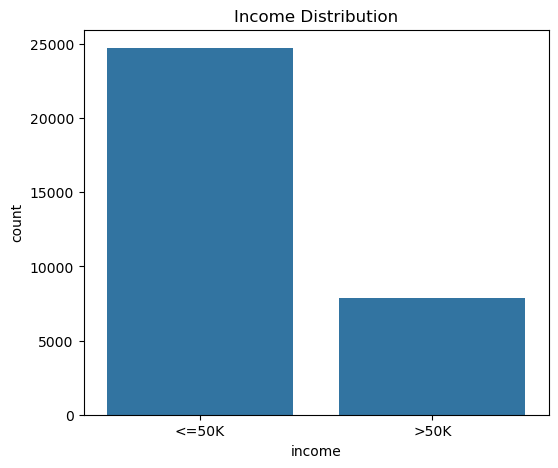

In [18]:
plt.figure(figsize=(6,5))
sns.countplot(x='income', data=df)
plt.title('Income Distribution')
plt.show()

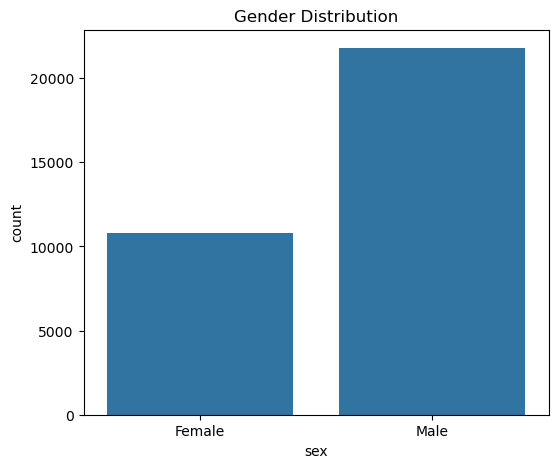

In [19]:
plt.figure(figsize=(6,5))
sns.countplot(x='sex', data=df)
plt.title('Gender Distribution')
plt.show()

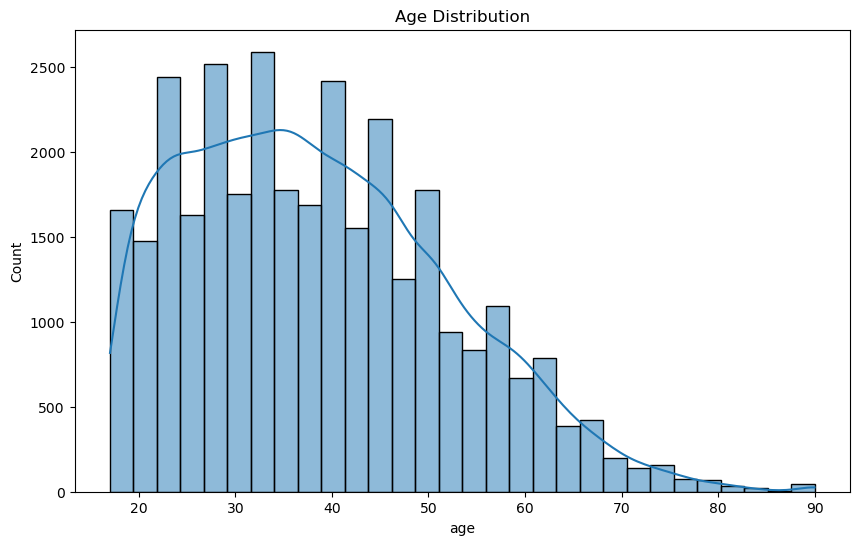

In [20]:
plt.figure(figsize=(10,6))
sns.histplot(df['age'], bins=30, kde=True)
plt.title('Age Distribution')
plt.show()

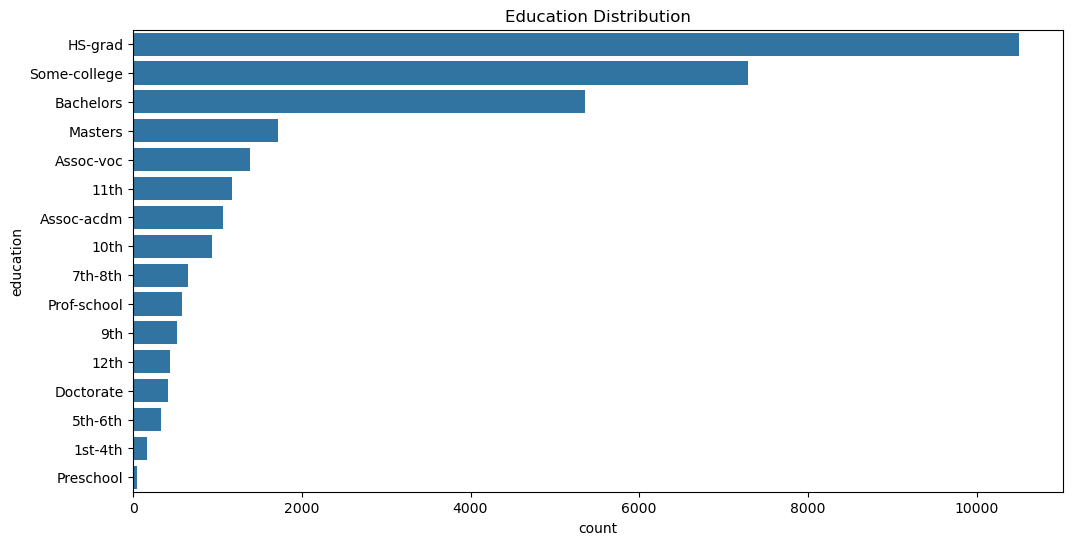

In [21]:
plt.figure(figsize=(12,6))
sns.countplot(y='education', data=df,
              order=df['education'].value_counts().index)
plt.title('Education Distribution')
plt.show()

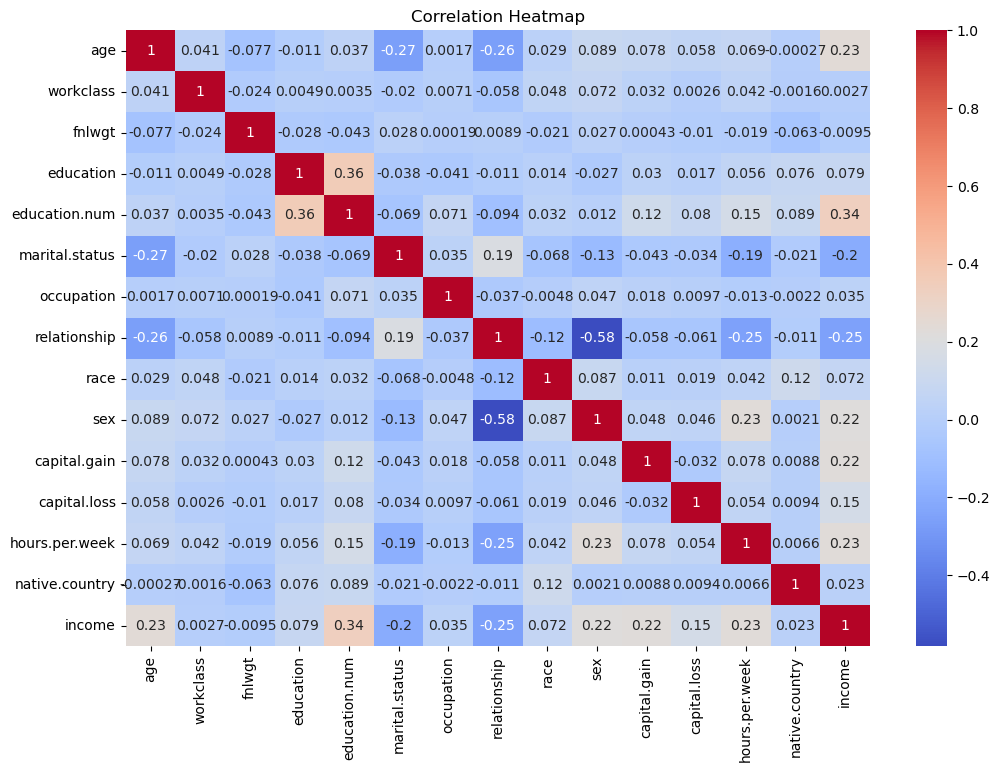

In [22]:
# Temporary encoding for heatmap

df_heatmap = df.copy()

encoder = LabelEncoder()

for col in df_heatmap.columns:
    if df_heatmap[col].dtype == 'object':
        df_heatmap[col] = encoder.fit_transform(df_heatmap[col])

plt.figure(figsize=(12,8))
sns.heatmap(df_heatmap.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [23]:
# Label Encoding

label_encoders = {}

for col in df.columns:
    if df[col].dtype == 'object':
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        label_encoders[col] = le

In [24]:
X = df.drop('income', axis=1)
y = df['income']

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [26]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [27]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_scaled, y_train)

lr_pred = lr_model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, lr_pred))

Accuracy: 0.8235836020267158


In [28]:
print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       0.85      0.94      0.89      4976
           1       0.70      0.44      0.54      1537

    accuracy                           0.82      6513
   macro avg       0.77      0.69      0.72      6513
weighted avg       0.81      0.82      0.81      6513



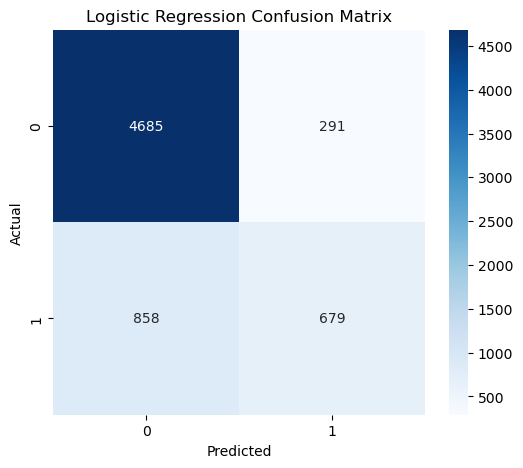

In [29]:
cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [30]:
DT_model = DecisionTreeClassifier(random_state=42)

DT_model.fit(X_train, y_train)

DT_pred = DT_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, DT_pred))

Accuracy: 0.8085367726086289


In [31]:
print(classification_report(y_test, DT_pred))

              precision    recall  f1-score   support

           0       0.88      0.87      0.87      4976
           1       0.59      0.61      0.60      1537

    accuracy                           0.81      6513
   macro avg       0.73      0.74      0.74      6513
weighted avg       0.81      0.81      0.81      6513



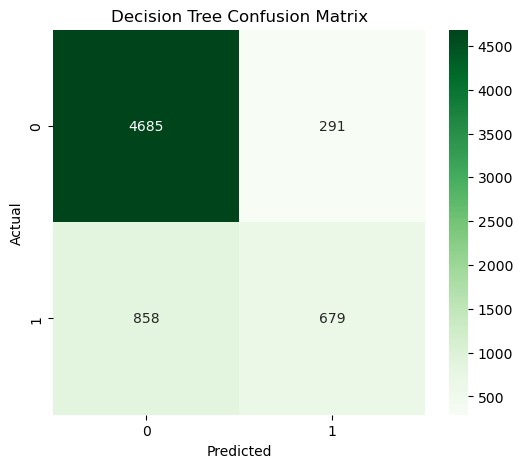

In [32]:
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title('Decision Tree Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [33]:
RF_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

RF_model.fit(X_train, y_train)

RF_pred = RF_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, RF_pred))

Accuracy: 0.8550591125441425


In [34]:
print(classification_report(y_test, RF_pred))

              precision    recall  f1-score   support

           0       0.89      0.93      0.91      4976
           1       0.73      0.61      0.67      1537

    accuracy                           0.86      6513
   macro avg       0.81      0.77      0.79      6513
weighted avg       0.85      0.86      0.85      6513



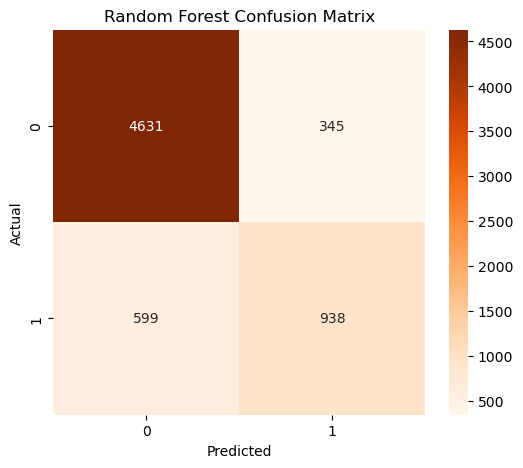

In [35]:
cm = confusion_matrix(y_test, RF_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges')
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [36]:
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_scaled, y_train)

knn_pred = knn_model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, knn_pred))

Accuracy: 0.8274220789190849


In [37]:
print(classification_report(y_test, knn_pred))

              precision    recall  f1-score   support

           0       0.87      0.91      0.89      4976
           1       0.65      0.57      0.61      1537

    accuracy                           0.83      6513
   macro avg       0.76      0.74      0.75      6513
weighted avg       0.82      0.83      0.82      6513



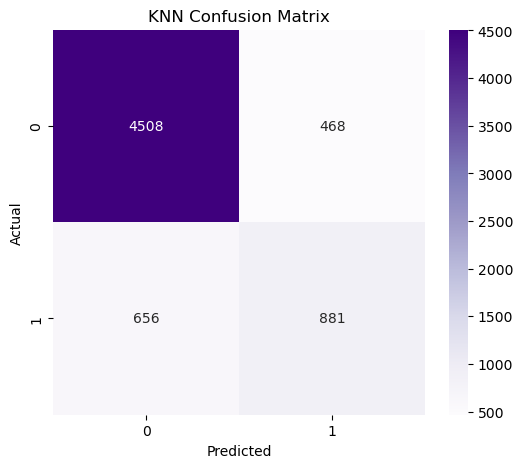

In [38]:
cm = confusion_matrix(y_test, knn_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')
plt.title('KNN Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [39]:
models = ['Logistic Regression', 'Decision Tree', 'Random Forest', 'KNN']
accuracies = [
    accuracy_score(y_test, lr_pred),
    accuracy_score(y_test, DT_pred),
    accuracy_score(y_test, RF_pred),
    accuracy_score(y_test, knn_pred)
]

results = pd.DataFrame({
    'Model': models,
    'Accuracy': accuracies
})

print(results)

                 Model  Accuracy
0  Logistic Regression  0.823584
1        Decision Tree  0.808537
2        Random Forest  0.855059
3                  KNN  0.827422


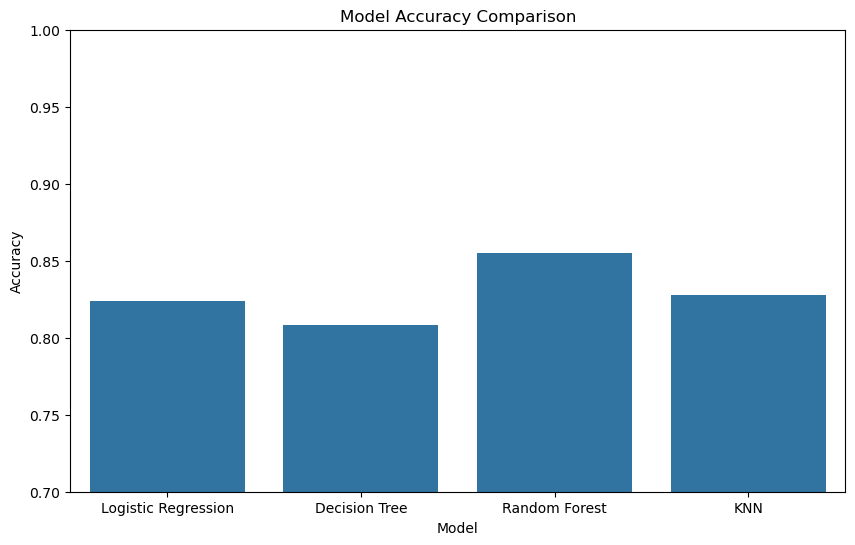

In [40]:
plt.figure(figsize=(10,6))
sns.barplot(x='Model', y='Accuracy', data=results)
plt.title('Model Accuracy Comparison')
plt.ylim(0.7, 1.0)
plt.show()